# Flow-corrected posterior marginalizing over WN

### Model creation

In [1]:
from flow_helpers import *

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
npsr = 1
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)


In [3]:
psrs = allpsrs[15:15+npsr]
Tspan = ds.getspan(psrs)

In [4]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw
rn_init_params = [{'log10_A': -12.0, 'gamma': 3}] * npsr
tnequad = True # more wnp to sample and marginalize over, but slower
ecorr = True # same as above...
fixed_wn = False

# Creating Fourier model
pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= rn_init_params, tnequad = tnequad, 
                                 ecorr = ecorr,powerlaw = powerlaw, fixed_wn = fixed_wn)


In [5]:
ds.priordict_standard
newdict = {'(.*_)?red_noise_coefficients\\(([0-9]*)\\)': [-100, 100]} # just much broader than we'll encounter

In [6]:
# computing _0 quantities
psr_noisedicts = [psr.noisedict for psr in psrs]
# in this case, logL has no params so no noisedict is not needed
# but we pass it in anyways since it will not affect the results
Ls, ahat0_list, logdet_sigma0_inv = compute_zero_quantities(pslmodels, psr_noisedicts)
            

In [7]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

In [8]:
logxs

[<function flow_helpers.simple_dict_transformation.<locals>.transformed(ys, ahat, L)>]

### Sampling $p(\xi, \theta | \eta_0)$

In [ ]:
n_xi = 2*rn_components
all_samples = []
num_warmup = 512
num_samples = 1024

for i in range(npsr):
    print(f"Sampling pulsar {pslmodels[i].name}")
    model_i, init_params_i = sample_rn_wn(logxs[i], ahat0_list[i], Ls[i])

    kernel = infer.NUTS(model_i)
    sampler = infer.MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, progress_bar=True)
    
    sampler.run(jax.random.key(i), init_params=init_params_i)
    all_samples.append(sampler.get_samples())
    sampler.print_summary()

Sampling pulsar J1640+2224


warmup:   0%|          | 5/1536 [00:47<6:05:03, 14.31s/it, 127 steps of size 1.10e-02. acc. prob=0.34]

### Fitting flow to MCMC samples for $p(\xi | \eta_0) = \int d \theta p(\xi, \theta | \eta_0)$

In [ ]:
trained_flows = []
rng = jax.random.key(5)

for i in range(npsr):
    print(f"Fitting flow for pulsar {pslmodels[i].name}")
    rng, flow_key, train_key = jax.random.split(rng, 3)

    xi_samples = jnp.array(all_samples[i]["xi"])
    n_coeff = xi_samples.shape[1]

    flow = masked_autoregressive_flow( flow_key,
        base_dist=StandardNormal((n_coeff,)),
        flow_layers=2, nn_width=32, nn_depth=4,
        invert=True)

    # fits a flow to MCMC samples where thetas (wn) have been thrown away
    trained_flow, train_key = fit_to_data(
        train_key, dist=flow, data=xi_samples,
        learning_rate=1e-2,max_epochs=1000,
        batch_size=128)
    
    trained_flows.append(trained_flow)

Fitting flow for pulsar J1125+7819


  2%|▏         | 21/1000 [00:02<01:41,  9.62it/s, train=76, val=77.6 (Max patience reached)]


In [ ]:
L0 = Ls[0]
ahat0 = ahat0_list[0]

### Estimating $\hat a_f, \Sigma_f$

In [ ]:
# computing _f quantities
num_flow_samples = 100000 # rather large to get good estimate of ahat_f and Sigma_f from samples
train_keys = jax.random.split(rng, npsr)

ahat_f, Sigma_f, L_f = gauss_approx_flow_mpsrs(trained_flows, train_keys, ahat0_list, 
                                                Ls, num_flow_samples=num_flow_samples)

# precomputing quantities needed in likelihood model
Sigma_f_inv, logdet_arr, b_flow, quad_f = eval_flow_quantity_mpsrs(ahat_f, Sigma_f, L_f)

_, f, df = construct_freqs(psrs, num_frequencies=rn_components)

# extracting TtNT for all psrs
TNT_flow, logdet_phi0 = TtNT_mpsrs(Sigma_f_inv, params_list=[rn_init_params[0]] * npsr,
                                f=f, df=df, powerlaw=powerlaw)

log_const = 0.5 * logdet_phi0


In [ ]:
flow_ys = np.array(trained_flows[0].sample(jax.random.key(2), sample_shape=(1000,)))  


In [ ]:
psrnames = [psr.name for psr in pslmodels]
rn_amp_keys, rn_gamma_keys = create_rn_keys(psrnames)

In [ ]:
crn_gamma_key = "crn_gamma"
crn_log10A_key = "crn_log10_A"
crn_components = 14

commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, rn_components, T=Tspan, name='red_noise')
commongp_crn =ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])
getN_common = commongp.Phi.getN 
getN_crn = commongp_crn.Phi.getN

In [ ]:
phi_crn_args = (crn_components, rn_amp_keys, rn_gamma_keys, crn_log10A_key, 
        crn_gamma_key, getN_common, getN_crn)

phi_crn_partial = jax.jit(lambda rho: phi_crn(rho, *phi_crn_args))

### Running CRN with flow-corrected posterior

In [ ]:
logL_flow_list = [flow.log_prob for flow in trained_flows]
base_model_args = (b_flow, phi_crn_partial, log_const, TNT_flow, npsr, rn_components,
                   rn_amp_keys, rn_gamma_keys, crn_log10A_key, crn_gamma_key)

flow_model = make_model_crn_flow( *base_model_args, logL_flow_list=logL_flow_list,
    ahat_0=jnp.stack(ahat0_list), L_0=jnp.stack(Ls), ahat_f=ahat_f, L_sigma_f=L_f,)

init_params = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0, crn_gamma_key: 4.0,
      "xi": jnp.zeros((npsr, 2 * rn_components))}

kernel_flow  = infer.NUTS(flow_model)
sampler_flow = infer.MCMC(kernel_flow, num_warmup=1000, num_samples=2000)
sampler_flow.run(jax.random.PRNGKey(2), init_params = init_params)
samples_flow = sampler_flow.get_samples()
sampler_flow.print_summary()

### Comparison of posteriors using fixed WN 

In [ ]:
m_crn = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=ecorr)]) for psr in psrs],
            commongp = [ds.makecommongp_fourier(psrs, ds.powerlaw, components=rn_components, T=Tspan, name='red_noise'),
                        ds.makecommongp_fourier(psrs, ds.powerlaw, components=crn_components, T=Tspan, name='crn',
                                                           common=[crn_log10A_key, crn_gamma_key])])

In [ ]:
def log_prior_rho_crn(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys] + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys] + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds_crn(rho):
        lp = log_prior_rho_crn(rho)
        return - m_crn.logL(rho) - lp
    
kernel_ds_crn = infer.NUTS(potential_fn=potential_ds_crn)
sampler_ds_crn = infer.MCMC(kernel_ds_crn, num_warmup=1000, num_samples=4000, num_chains=1, progress_bar=True)
init_rho_crn = {**{key: -14.0 for key in rn_amp_keys},
    **{key: 4.0 for key in rn_gamma_keys},
    crn_log10A_key: -12.0,
    crn_gamma_key: 4.0}

sampler_ds_crn.run(jax.random.key(1), init_params=init_rho_crn)

samples_ds_crn = sampler_ds_crn.get_samples()
sampler_ds_crn.print_summary()


sample: 100%|██████████| 5000/5000 [01:26<00:00, 57.79it/s, 13 steps of size 6.30e-02. acc. prob=0.89] 



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1125+7819_red_noise_gamma      0.38      0.30      0.32      0.00      0.80    233.92      1.00
  J1125+7819_red_noise_log10_A    -12.54      0.12    -12.54    -12.73    -12.37    232.99      1.00
                     crn_gamma      3.27      1.91      3.16      0.04      6.02    230.89      1.00
                   crn_log10_A    -16.54      1.99    -16.50    -19.99    -13.78    276.00      1.00

Number of divergences: 3607


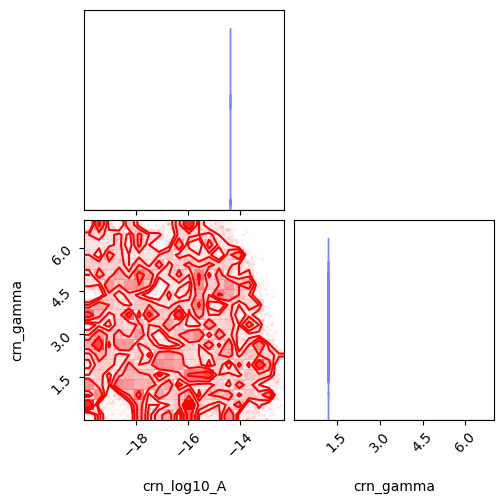

In [ ]:
crn_hyper_ds = {k: samples_ds_crn[k] for k in [crn_log10A_key, crn_gamma_key]}
crn_samples_flow = {k: samples_flow[k] for k in [crn_log10A_key, crn_gamma_key]}
figure = corner.corner(crn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color = 'blue')
corner.corner(crn_hyper_ds, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color = 'red', fig = figure)

plt.show()

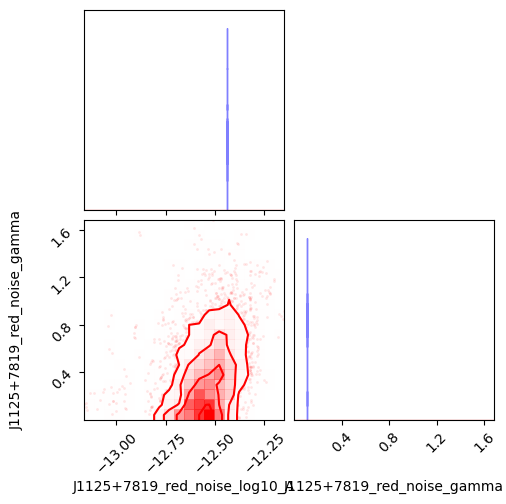

In [ ]:
irn_samples_ds_crn = {k: samples_ds_crn[k] for k in rn_amp_keys + rn_gamma_keys}
irn_samples_flow = {k: samples_flow[k] for k in rn_amp_keys + rn_gamma_keys}
figure = corner.corner(irn_samples_flow, hist_kwargs = {"density": True, "alpha": 0.5, "color": "blue"}, color='blue')
corner.corner(irn_samples_ds_crn, hist_kwargs = {"density": True, "alpha": 0.5, "color": "red"}, color='red', fig=figure)
plt.show()


In [ ]:
samples_ys = trained_flow.sample(jax.random.key(0), sample_shape=(100000,))
sample_flow_ys = samples_flow["y"]

(array([27.54660753, 33.90351697, 38.84777986, 51.20843708, 29.66557735,
        51.56159872, 48.383144  , 25.42763772, 58.62483142, 56.85902324,
        67.4538723 , 68.86651884, 82.99298424, 64.98174085]),
 array([0.96480509, 0.96622088, 0.96763666, 0.96905244, 0.97046822,
        0.971884  , 0.97329979, 0.97471557, 0.97613135, 0.97754713,
        0.97896292, 0.9803787 , 0.98179448, 0.98321026, 0.98462605]),
 <BarContainer object of 14 artists>)

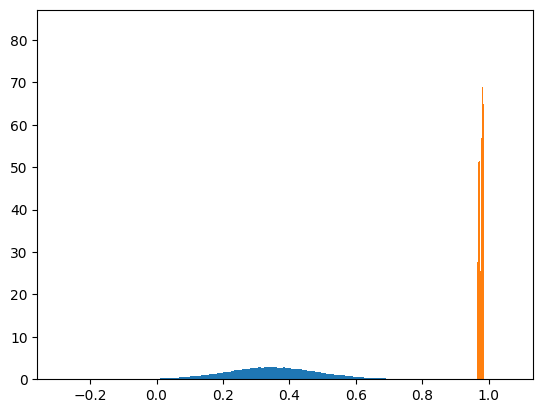

In [ ]:
plt.hist(samples_ys[:,0], bins = 'auto', density = True)
plt.hist(sample_flow_ys[:,0,0], bins = 'auto', density = True)